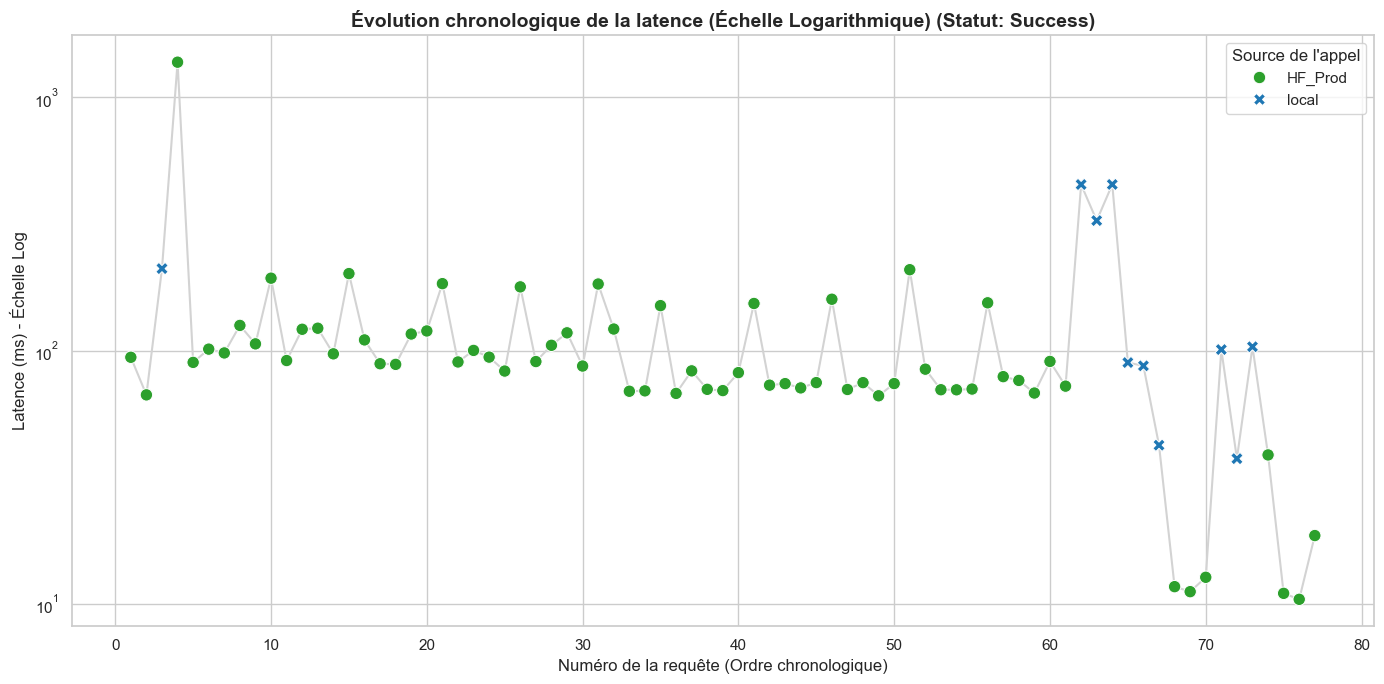

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

# 1. Configuration et Connexion à Neon DB
load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")
if not DATABASE_URL:
    raise RuntimeError("DATABASE_URL non définie — vérifie ton .env")

engine = create_engine(
    DATABASE_URL,
    echo=False,
    pool_recycle=1800,
    pool_pre_ping=True,
)

# 2. Récupération des données
query = "SELECT timestamp, source, latence_ms FROM prediction_logs WHERE statut = 'success';"
df = pd.read_sql(query, con=engine)

# 3. Tri chronologique et indexation séquentielle
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)
df["sequence_globale"] = df.index + 1

# 4. Tracé du graphique
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# La ligne unique chronologique
plt.plot(
    df["sequence_globale"],
    df["latence_ms"],
    color="lightgray",
    linestyle="-",
    linewidth=1.5,
    zorder=1,
)

# Les points colorés (Bleu = local, Vert = HF_Prod)
sns.scatterplot(
    data=df,
    x="sequence_globale",
    y="latence_ms",
    hue="source",
    palette={"local": "#1f77b4", "HF_Prod": "#2ca02c"},
    s=80,
    style="source",
    zorder=2,
)

# Activer l'échelle logarithmique sur l'axe Y
plt.yscale("log")

# Personnalisation des axes
plt.title(
    "Évolution chronologique de la latence (Échelle Logarithmique) (Statut: Success)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Numéro de la requête (Ordre chronologique)", fontsize=12)
plt.ylabel("Latence (ms) - Échelle Log", fontsize=12)
plt.legend(title="Source de l'appel", fontsize=11)
plt.tight_layout()

# Affichage
plt.show()